In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import sys
import os
sys.path.append(os.path.abspath('..'))
sys.path.append(os.path.abspath('../../..'))

from source.include.components import *
from source.include.circuits import *
from source.include.helpers import *
from source.include.demod import *

from resonator_fitting.include import circle_fitting as cf
from resonator_fitting.include import resonance_fitting as rf
from resonator_fitting.include import all_resonances as ar


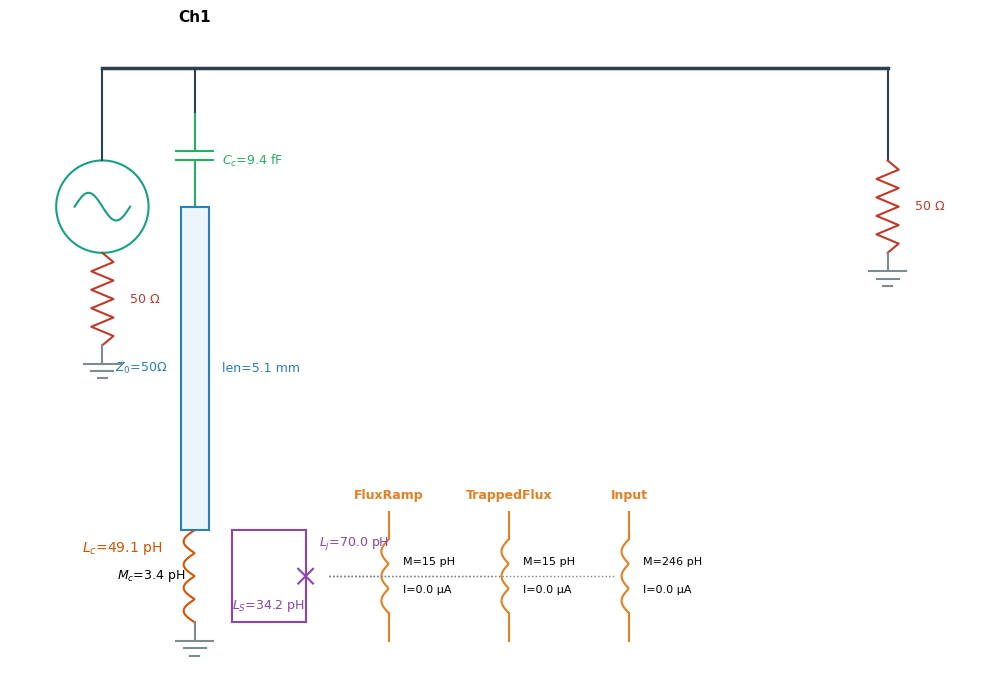

(20000, 2, 2)


/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/lukewanner/miniconda3/envs/umux/lib/python3.10/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


(20000, 2, 2)


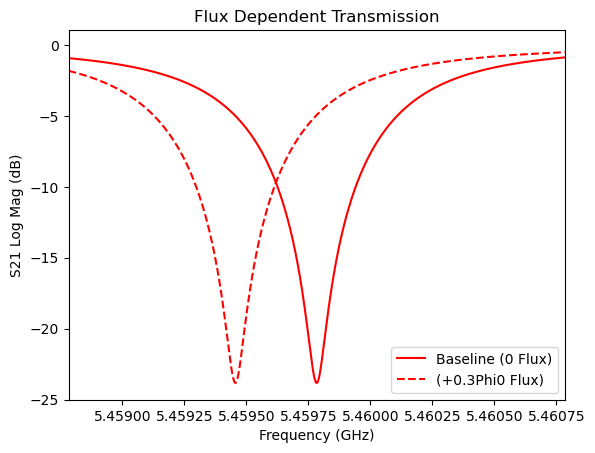

In [2]:
VNA = VNA_Simulator(z0=50)
squid_ch = SQUID(L_j=70e-12, L_s=34.2e-12, lamb=None, phi_ext=0.0) 
squid_ch.add_flux_line("FluxRamp", M=15e-12, initial_current=0.0)
squid_ch.add_flux_line("TrappedFlux", M=15e-12, initial_current=0.0)
squid_ch.add_flux_line("Input", M=246e-12)   

ind_ch = Inductor(49.1e-12)
tuned_L_ch = ScreenedInductor(primary_inductor=ind_ch, screening_device=squid_ch, M=3.4e-12)
length =5.1e-3 
Cc_val = 9.4e-15 
Qi_val = 85e3

cap_ch = Capacitor(C=Cc_val)
phys_res = Resonator(length=length, load=tuned_L_ch, v_p=1.15e8, Qi=Qi_val)

channel = Channel(name=f"Ch{1}") 
channel.add(cap_ch)
channel.add(phys_res)

VNA.add(channel, 'shunt')

VNA.draw_schematic(use_color=True, max_draw=1)

freqs = np.linspace((5.46-0.002)*1e9,(5.46+0.002)*1e9,20000)
S = VNA.get_s_matrix(freqs)

plt.plot(freqs*1e-9, 20*np.log10(S[1,0]), color = 'r', label = "Baseline (0 Flux)")
f_center = freqs[np.argmin(20*np.log10(S[1,0]))]


squid_ch.flux_lines["FluxRamp"].set_flux(0.3*Phi0)
S = VNA.get_s_matrix(freqs)

plt.plot(freqs*1e-9, 20*np.log10(S[1,0]), color = 'r', linestyle = "--", label = "(+0.3Phi0 Flux)")


plt.xlim((f_center-1e6)*1e-9,(f_center+1e6)*1e-9)
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 Log Mag (dB)")
plt.title("Flux Dependent Transmission")
plt.legend()
# plt.xlim([5.6e9,5.61e9])




In [3]:
nPhi0 = 1
flux_array = np.linspace(0,nPhi0*Phi0,1024)
I_array = flux_array/15e-12
squid_ch.flux_lines["FluxRamp"].I = 0

S_baseline = VNA.get_s_matrix(freqs)
baseline_peaks_idx = find_all_peaks(freqs, S_baseline[1, 0])
baseline_frs = freqs[baseline_peaks_idx]

frs = np.zeros(1024)
for i, current in enumerate(I_array):
    squid_ch.flux_lines["FluxRamp"].I = current
    guess = baseline_frs[0]
    frs[i] = channel.get_resonance(f_guess=guess)
    





(20000, 2, 2)


In [4]:
nPhi0 = np.pi
flux_array_pi = np.linspace(0,nPhi0*Phi0,1024)
I_array = flux_array_pi/15e-12
squid_ch.flux_lines["FluxRamp"].I = 0

S_baseline = VNA.get_s_matrix(freqs)
baseline_peaks_idx = find_all_peaks(freqs, S_baseline[1, 0])
baseline_frs = freqs[baseline_peaks_idx]

frs_pi = np.zeros(1024)
for i, current in enumerate(I_array):
    squid_ch.flux_lines["FluxRamp"].I = current
    guess = baseline_frs[0]
    frs_pi[i] = channel.get_resonance(f_guess=guess)
    





(20000, 2, 2)


1024


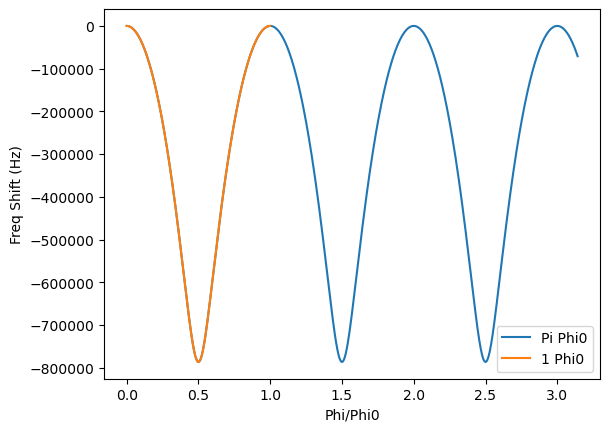

In [5]:

plt.plot(flux_array_pi/Phi0, (frs_pi-baseline_frs[0]), label = "Pi Phi0")
plt.plot(flux_array/Phi0, (frs-baseline_frs[0]), label = "1 Phi0")
plt.ylabel("Freq Shift (Hz)")
plt.xlabel("Phi/Phi0")
plt.legend()
print(len(frs_pi))

In [6]:
import numpy as np

# Define the baseline
baseline = baseline_frs[0]

# 1. Save the 1 Phi0 data
np.savez(
    'flux_response_1_phi0.npz', 
    baseline=baseline, 
    flux_norm=flux_array / Phi0, 
    freqs=frs-baseline
)

# 2. Save the Pi Phi0 data
np.savez(
    'flux_response_pi_phi0.npz', 
    baseline=baseline, 
    flux_norm=flux_array_pi / Phi0, 
    freqs=frs_pi-baseline
)

print("Data saved successfully to 'resonance_data_1_phi0.npz' and 'resonance_data_pi_phi0.npz'")

Data saved successfully to 'resonance_data_1_phi0.npz' and 'resonance_data_pi_phi0.npz'


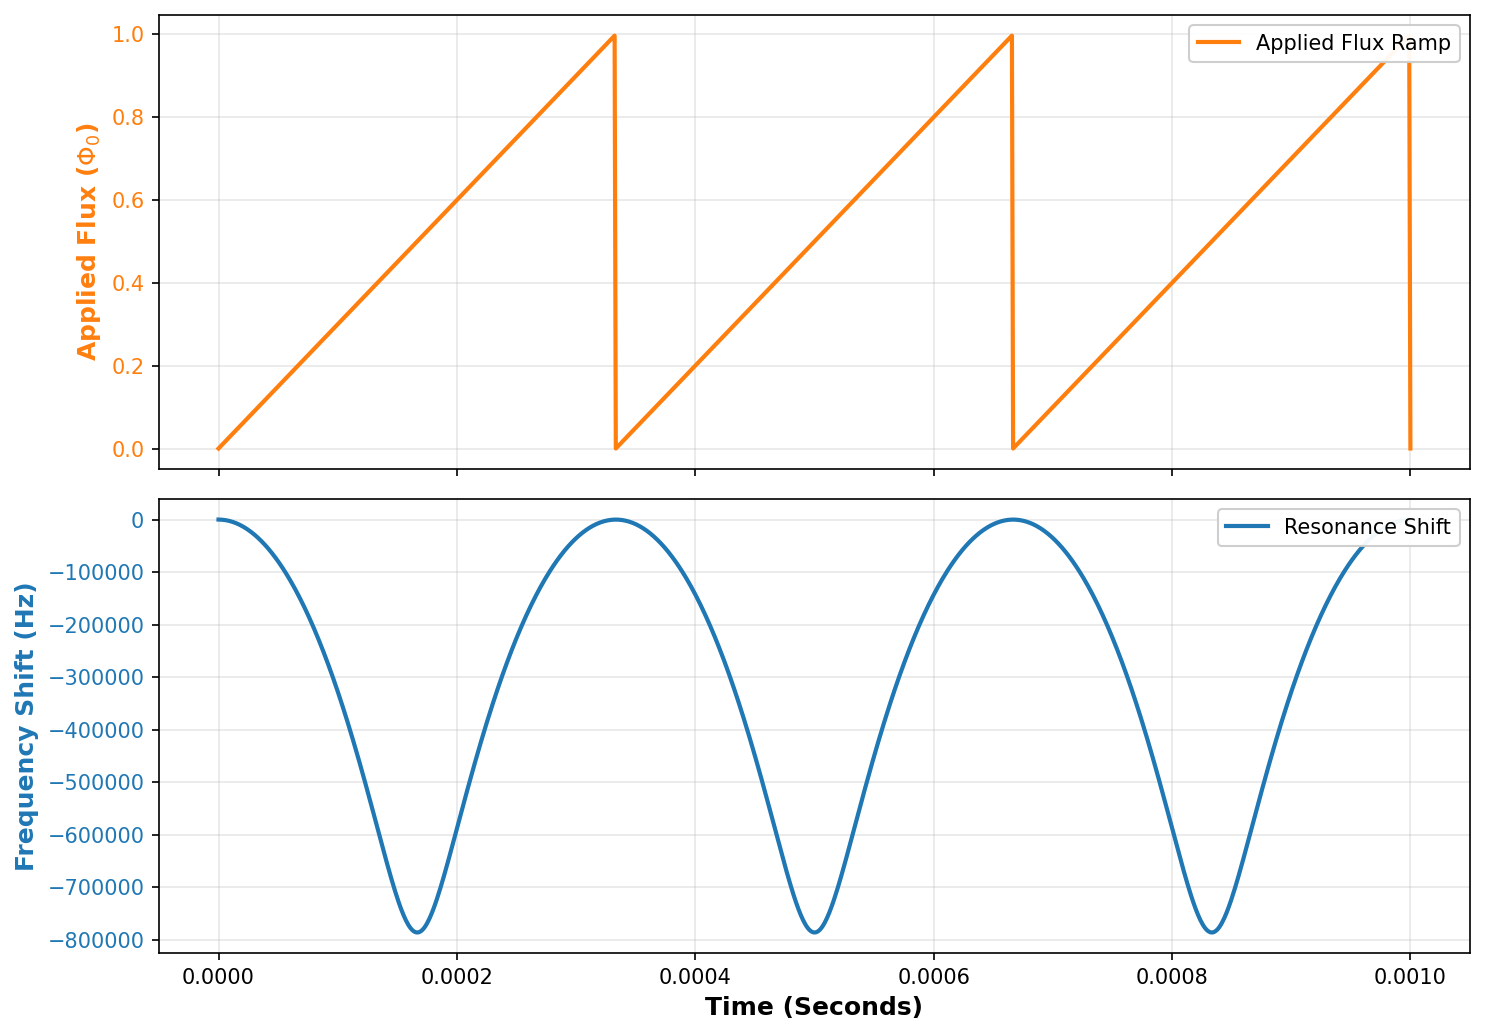

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# --- Your existing simulation generation ---
times = np.linspace(0, 1e-3, 1000)
flux_ramp = Flux_Ramp(nPhi0=1, freq=3e3, time_array=times)
flux_array = flux_ramp.phi_ramp
squid_ch.flux_lines["FluxRamp"].set_flux(flux_array)
fr_array = channel.get_resonance(f_guess=baseline_frs[0])
# -------------------------------------------

# Setup the figure with 2 stacked subplots sharing the X-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), dpi=150, sharex=True)

# Colors for clear contrast
color_ramp = '#ff7f0e'  # Orange
color_squid = '#1f77b4' # Blue

# --- Top Plot: Flux Ramp ---
ax1.plot(times, flux_array / Phi0, color=color_ramp, linewidth=2, label="Applied Flux Ramp")
ax1.set_ylabel("Applied Flux ($\Phi_0$)", color=color_ramp, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_ramp)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper right', framealpha=0.95)
# ax1.set_title("SQUID Multiplexer Timing Diagram", fontsize=14, fontweight='bold', pad=15)

# --- Bottom Plot: Resonance Frequency Shift ---
ax2.plot(times, fr_array - baseline, color=color_squid, linewidth=2, label="Resonance Shift")
ax2.set_xlabel("Time (Seconds)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Frequency Shift (Hz)", color=color_squid, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_squid)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', framealpha=0.95)

# Tight layout ensures the labels don't get cut off
plt.tight_layout()
plt.show()

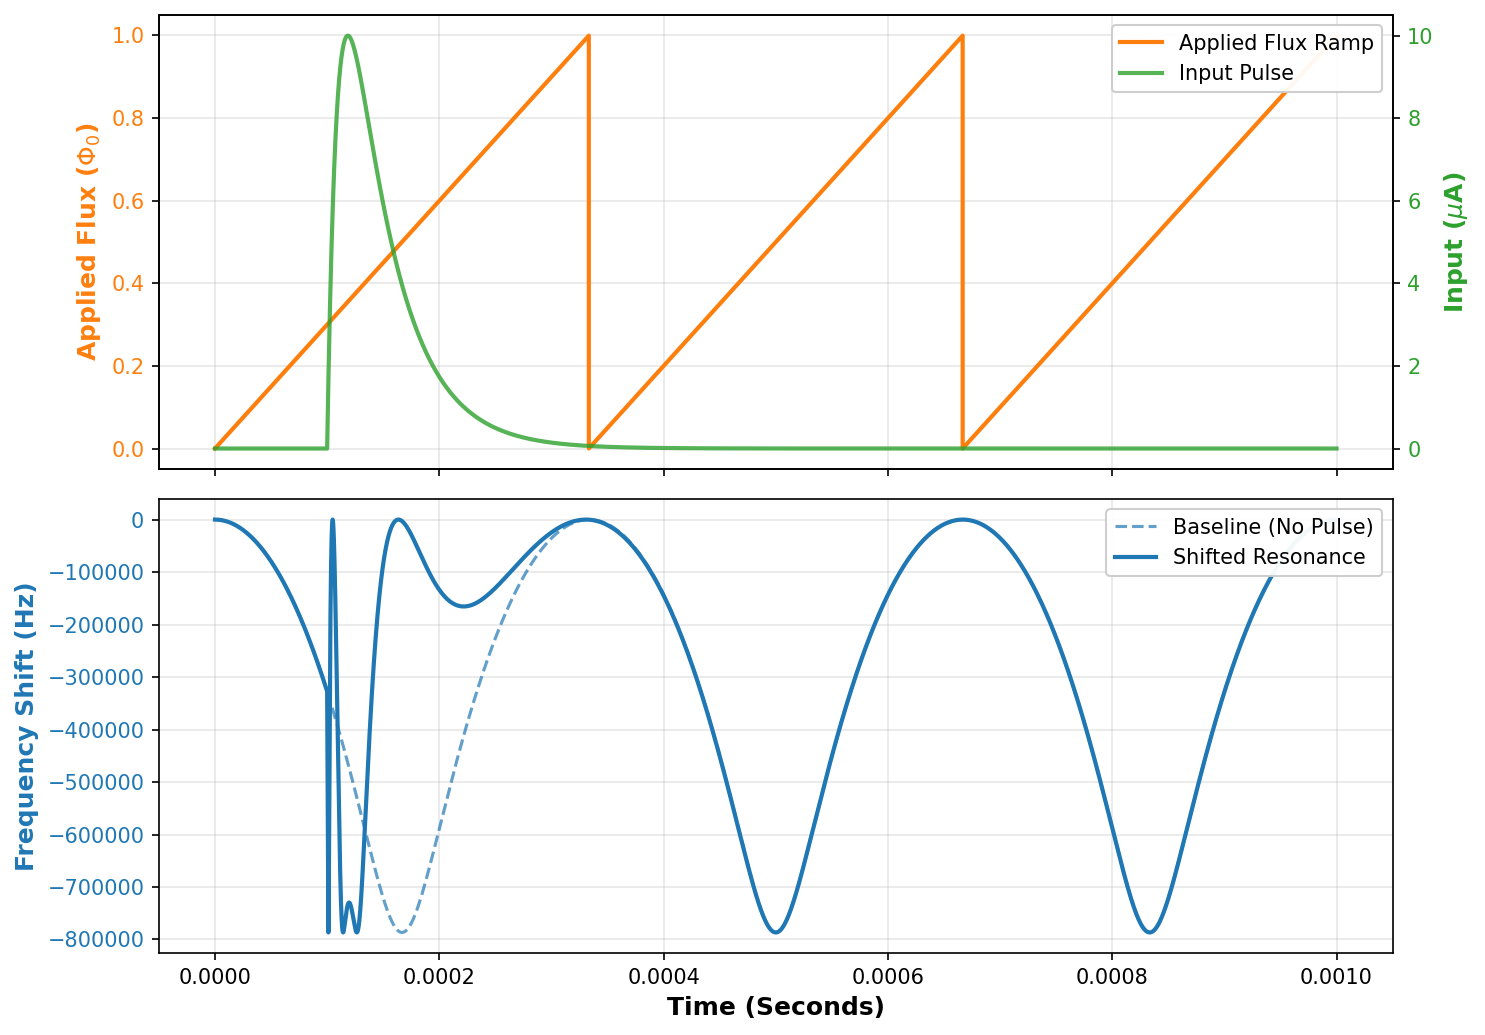

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Timing Setup ---
# Using the higher resolution timing from your second block to capture pulse edges
fs_required = 100e6     
dt = 1.0 / fs_required  
sim_time = 1e-3
t_array = np.arange(0, sim_time, dt) 

# --- 2. Signal Generation ---
# Generate the standard Flux Ramp
flux_ramp = Flux_Ramp(nPhi0=1, freq=3e3, time_array=t_array)
flux_array = flux_ramp.phi_ramp

# Generate the Input Pulse
# Assuming parameters (time_array, delay, width, rise_time, fall_time)
# Placed around 0.4ms so it clearly intersects the middle of a ramp cycle
PG = Pulse_Generator(t_array, 40e-6, 10e-6, 10e-6, 100e-6 )

# --- 3. SQUID Simulation ---
# Set the baseline ramp
squid_ch.flux_lines["FluxRamp"].set_flux(flux_array)

# Get baseline response (NO PULSE) for comparison
squid_ch.flux_lines["Input"].I = np.zeros_like(t_array)
fr_array_base = channel.get_resonance(f_guess=baseline_frs[0])

# Apply the pulse and get the perturbed response
squid_ch.flux_lines["Input"].I = PG.I_pulse
fr_array_pulse = channel.get_resonance(f_guess=baseline_frs[0])

# --- 4. Plotting ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), dpi=150, sharex=True)

color_ramp = '#ff7f0e'  # Orange
color_pulse = '#2ca02c' # Green
color_squid = '#1f77b4' # Blue

# -- Top Plot: Flux Ramp (Primary Y) & Input Pulse (Secondary Y) --
line1 = ax1.plot(t_array, flux_array / Phi0, color=color_ramp, linewidth=2, label="Applied Flux Ramp")
ax1.set_ylabel("Applied Flux ($\Phi_0$)", color=color_ramp, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_ramp)
ax1.grid(True, alpha=0.3)

ax1_pulse = ax1.twinx()
line2 = ax1_pulse.plot(t_array, 1e6 * PG.I_pulse, color=color_pulse, linewidth=2, alpha=0.8, label="Input Pulse")
ax1_pulse.set_ylabel("Input ($\mu$A)", color=color_pulse, fontsize=12, fontweight='bold')
ax1_pulse.tick_params(axis='y', labelcolor=color_pulse)

# Combine legends for the top plot
handles = line1 + line2
labels = [h.get_label() for h in handles]
ax1.legend(handles, labels, loc='upper right', framealpha=0.95)

# -- Bottom Plot: Resonance Frequency Shift --
# Plot the baseline first so it sits underneath
ax2.plot(t_array, fr_array_base - baseline_frs[0], color=color_squid, linestyle='--', linewidth=1.5, alpha=0.7, label="Baseline (No Pulse)")

# Plot the phase-shifted response
ax2.plot(t_array, fr_array_pulse - baseline_frs[0], color=color_squid, linewidth=2, label="Shifted Resonance")

ax2.set_xlabel("Time (Seconds)", fontsize=12, fontweight='bold')
ax2.set_ylabel("Frequency Shift (Hz)", color=color_squid, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_squid)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

/var/folders/5y/0rp23b8505l125t55yv9lq140000gn/T/ipykernel_21006/3799952642.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend()


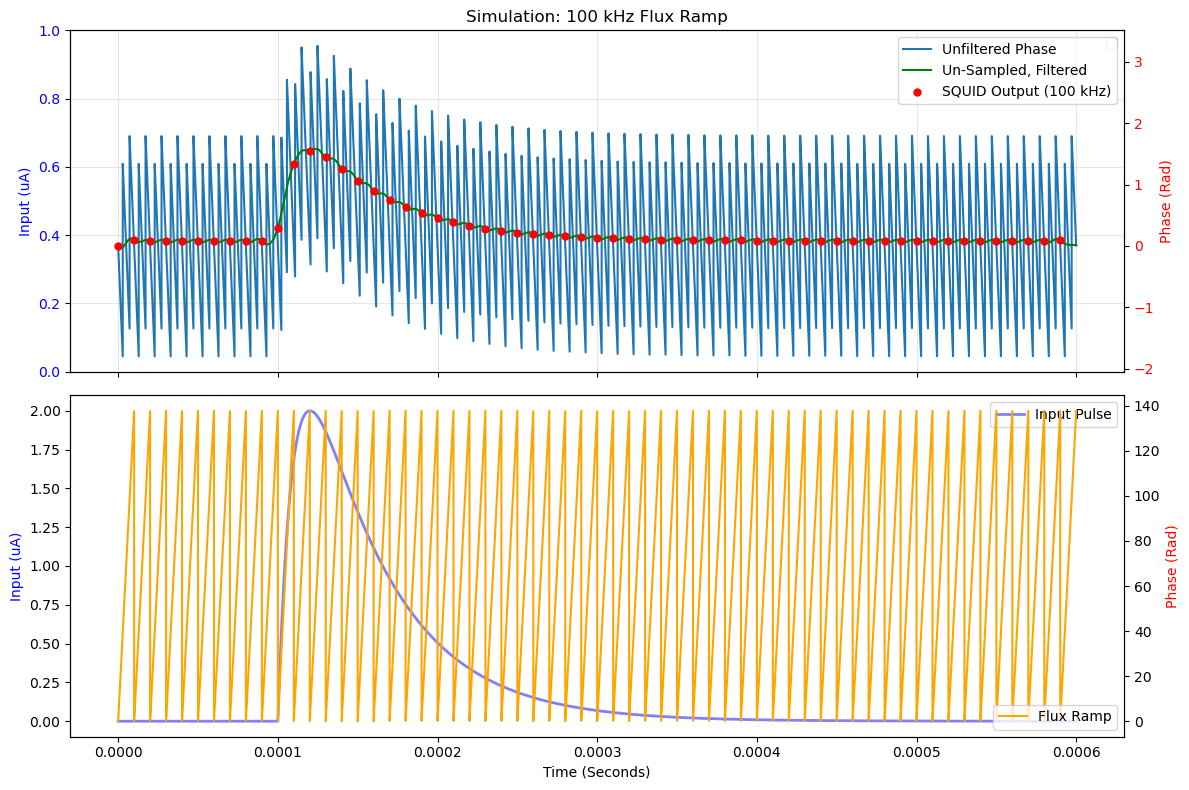

In [27]:
import numpy as np
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt


fs_required = 100e6     
dt = 1.0 / fs_required  
sim_time = 600e-6
t_array = np.arange(0, sim_time, dt) 

PG = Pulse_Generator(t_array, 10e-6, 50e-6, 2e-6, 100e-6)

test_rates = [100e3]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
color1 = 'blue'
color2 = 'red'


for i, rate in enumerate(test_rates):
    ax1 = axes[0]

    flux_ramp = Flux_Ramp(nPhi0=1, freq=rate, time_array=t_array)
    flux_array = flux_ramp.phi_ramp

    squid_ch.flux_lines["FluxRamp"].set_flux(flux_array)
    squid_ch.flux_lines["Input"].I = PG.I_pulse
    frs = channel.get_resonance(f_guess=baseline_frs[0])
    signal_ac = frs - np.mean(frs)
    
    demod = Demodulator(rate, sim_time=sim_time)
    t_sampled, phase_sampled = demod.demodulate(signal_ac)

    
    ax1.set_ylabel("Input (uA)", color=color1)
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.grid(True, alpha=0.3)
    
    ax2 = ax1.twinx()  
    
    ax2.plot(demod.t_array, -demod.unfiltered_phase, label = "Unfiltered Phase")
    ax2.plot(demod.t_array,-demod.filtered_phase, label = "Un-Sampled, Filtered", color = 'green')
    ax2.scatter(t_sampled, phase_sampled, color=color2, s=25, zorder=5, label=f"SQUID Output ({rate/1e3:.0f} kHz)")
    ax2.set_ylabel("Phase (Rad)", color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    

    ax1.legend()
    ax2.legend()
    ax1.set_title(f"Simulation: {rate/1e3:.0f} kHz Flux Ramp")

ax4 = axes[1]
ax3 = ax4.twinx()
ax4.set_ylabel("Input (uA)", color=color1)
ax3.set_ylabel("Phase (Rad)", color=color2)
ax4.plot(t_array, 1e6*PG.I_pulse, color=color1, linewidth=2, alpha=0.5, label="Input Pulse")
ax3.plot(demod.t_array, 1e6*flux_array/squid_ch.flux_lines["FluxRamp"].M, label ="Flux Ramp", color = 'orange')
axes[-1].set_xlabel("Time (Seconds)")
ax4.legend()
ax3.legend()
plt.tight_layout()
plt.show()
